# 第5回　大規模スクリーニングと材料発見：900万分子を評価する

ここまでで、化学構造から6種のガス透過係数を予測するモデルができ（第3回）、そのモデルが何を学んだかも分かりました（第4回）。

最終回では、このモデルを**まだ誰も作っていない仮想高分子**に適用します。論文は900万個以上を評価し、Robeson 上限を超える候補を数万個見つけました。論文 Fig.1 の **Step 4・Step 5** に対応します。

そして最後に、**「機械学習で材料を発見した」という主張がどこまで検証されているのか**をシリーズ全体を振り返りながら考えます。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane/blob/main/05_screening_and_discovery.ipynb)

## 本ノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | 第1〜4回を終えた方 |
| **前提知識** | Pythonの基礎文法。第2回のMFF、第3回のDNNアンサンブルを使います |
| **本回で学ぶこと** | ①学習済みモデルによる大規模スクリーニング、②論文 Fig.5・Table 3 の再現、③外挿の危うさを不確かさで測る方法、④材料探索研究の検証のしかた |
| **所要時間** | 約50分（スクリーニングに2〜3分） |
| **動作環境** | Python 3.10以上、rdkit / TensorFlow(Keras) / scikit-learn |
| **データ** | `code/datasets/datasetB.csv`（99.6万件）、`datasetC_0.csv`（100万件）、`datasetD.csv`（1,124件）、`code/pretrained_models/DNN_BLR_fing/top_polymers.csv`（著者らの候補リスト89,809件） |
| **ライセンス** | 論文 CC BY-NC 4.0。原著コード `code/step4_screen.py`・`code/visualizations.ipynb` を教材向けに書き直しています |

> **計算量について**
>
> 論文は Dataset C の全820万件を評価していますが、本ノートブックでは既定で**各2万件**をサンプリングして使います（`SCREEN_N` で変更可）。傾向を掴むには十分で、全件を回した場合との違いも本文で確認します。

---
## 0. セットアップ

In [1]:
# Google Colab で実行する場合のセットアップ（ローカル環境では何もしない）
import os
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules
REPO_DIR = 'Advanced_Tutorial_11_Polymer-Gas-Membrane'
PACKAGES = ['rdkit']

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane.git'], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + PACKAGES, check=False)
    print('Colab setup finished. cwd =', os.getcwd())
else:
    print('Running locally. cwd =', os.getcwd())

Running locally. cwd = /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML


In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from module.pgm_setup import setup_notebook, print_library_versions, GAS_NAMES, RANDOM_STATE
from module.pgm_data import load_dataset_a, get_targets, load_features, load_screening_smiles
from module.pgm_features import smiles_to_mols, build_mff_vocabulary, compute_mff
from module.pgm_models import load_pretrained_ensemble, ensemble_predict
from module.pgm_robeson import (
    plot_robeson_panel, draw_upper_bounds, count_above_bound,
    distance_above_bound, robeson_coordinates, SEPARATIONS,
)

PATHS = setup_notebook()
OUTPUT_DIR, DATA_DIR, MODEL_DIR = PATHS['OUTPUT_DIR'], PATHS['DATA_DIR'], PATHS['MODEL_DIR']

SCREEN_N = 20_000   # Dataset B・C から評価する件数。全件にするなら None
print()
print_library_versions(('numpy', 'pandas', 'sklearn', 'tensorflow', 'rdkit'))

Environment      : local
Project root     : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML
Dataset directory: /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/code/datasets
Output directory : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/output

numpy        2.2.6
pandas       2.3.3
sklearn      1.7.2


I0000 00:00:1786360200.740736       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1786360204.066105       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


tensorflow   2.21.0


rdkit        2026.03.5


> **本回で使うヘルパー**：`module/pgm_robeson.py`、`module/pgm_features.py`、`module/pgm_models.py`
>
> `pgm_robeson.py` は原著 `visualizations.ipynb` の `plotRobeson()` を関数として整理したもので、Robeson 上限線の係数（1991年・2008年・2015/2019年）は原著の実装から引き写しています。スクリーニング処理そのものは原著 `step4_screen.py` に対応します。

---
## 1. スクリーニングの考え方

やることは単純です。

1. 未知の高分子の SMILES から MFF を計算する（第2回の**学習セットで作った語彙**を使う）
2. 学習済み DNN アンサンブルに通して6ガスの透過係数を予測する
3. Robeson 上限を超えるものを拾い上げる

**ここで最も重要なのは、手順1で必ず学習時と同じ語彙を使うこと**です。新しいデータセットで語彙を作り直したら、特徴量の意味が変わってしまい、学習済みモデルの重みは無意味になります。

まず語彙とモデルを準備します。

In [3]:
dataset_a = load_dataset_a(DATA_DIR)
targets_a = get_targets(dataset_a, 'BLR')
y_scaler = StandardScaler().fit(targets_a.to_numpy())

mols_a, _ = smiles_to_mols(dataset_a['Smiles'])
vocabulary = build_mff_vocabulary(mols_a)
ensemble = load_pretrained_ensemble(MODEL_DIR / 'DNN_BLR_fing', 114)

print(f"学習セットの語彙: {len(vocabulary['selected_index'])} 部分構造")
print(f"アンサンブル     : {len(ensemble)} モデル")

学習セットの語彙: 114 部分構造
アンサンブル     : 16 モデル


In [4]:
def screen(smiles_series, label):
    """SMILES の列から MFF を計算し、透過係数を予測する（原著 step4_screen.py に相当）。"""
    start = time.time()
    mols, valid_mask = smiles_to_mols(smiles_series, keep_invalid=False)
    features = compute_mff(mols, vocabulary)
    prediction_scaled, variance = ensemble_predict(ensemble, features.to_numpy(dtype='float64'))
    prediction = y_scaler.inverse_transform(prediction_scaled)
    print(f"{label:12s}: {len(smiles_series):>7,} SMILES -> 有効 {int(valid_mask.sum()):>7,} 件, "
          f"{time.time() - start:.0f} 秒")
    return {'smiles': np.asarray(smiles_series)[valid_mask], 'features': features,
            'prediction': prediction, 'variance': variance}

---
## 2. Dataset D（ラダーポリマー）を全件スクリーニングする

Dataset D は1,124件と小さいので全件を評価できます。また、著者らが計算した MFF（`datasetDX_fing.csv`）が同梱されているので、**自分の計算が著者らのものと一致するか**を検証できます。

In [5]:
dataset_d = load_screening_smiles(DATA_DIR, 'datasetD')
result_d = screen(dataset_d['Smiles'], 'Dataset D')

# 著者らが計算した MFF と突き合わせる
reference_d = pd.read_csv(DATA_DIR / 'datasetDX_fing.csv', index_col=0)
mine = result_d['features'].to_numpy()
theirs = reference_d.to_numpy()

mismatch = (mine != theirs)
print()
print(f"形状の一致            : {mine.shape == theirs.shape}")
print(f"列名の一致            : {list(result_d['features'].columns) == list(reference_d.columns)}")
print(f"値が食い違うセルの数  : {mismatch.sum():,} / {mine.size:,}  ({mismatch.mean() * 100:.4f}%)")
print(f"値が食い違う分子の数  : {mismatch.any(axis=1).sum()} / {len(mine)}")

Dataset D   :   1,124 SMILES -> 有効   1,124 件, 5 秒



形状の一致            : True
列名の一致            : True
値が食い違うセルの数  : 52 / 128,136  (0.0406%)
値が食い違う分子の数  : 11 / 1124


**99.96% のセルが一致しました。** 第2回で Dataset A の MFF は完全一致したので、ここでも一致すると期待されますが、**11分子だけわずかに違います**。

これは RDKit のバージョン差によるものと考えられます。芳香族性の判定や構造の正規化のルールは版を追うごとに改訂されており、特殊な環構造を持つ分子で結果が変わることがあります（Dataset D はラダーポリマーなので、複雑な縮環構造を多く含みます）。

差が0.04%なら予測への影響は無視できますが、**「特徴量の再現性は分子によっては保証されない」**という事実は記録しておくべきです。第2回の教訓（特徴量には名前とバージョンを添えて保存する）がここでも効いてきます。

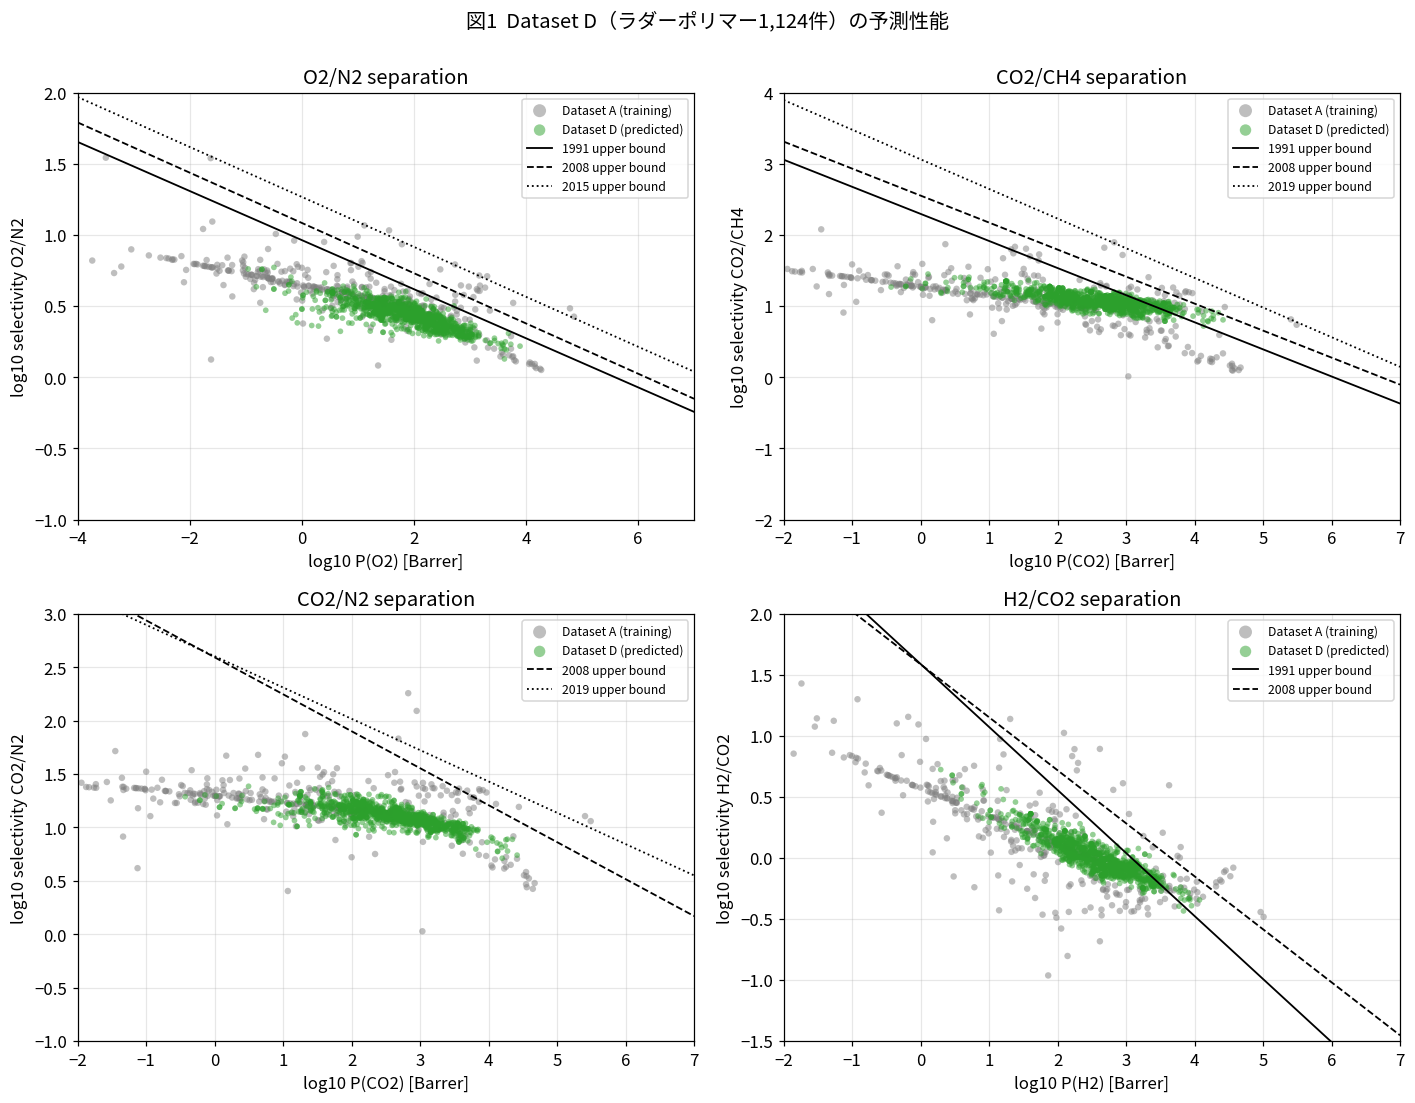

,separation,n_above_2008,fraction,max_distance
0,O2/N2,0,0.00000,-0.103341
1,CO2/CH4,1,0.00089,0.003850
2,CO2/N2,0,0.00000,-0.199407
3,H2/CO2,0,0.00000,-0.119092


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, separation in zip(axes.ravel(), SEPARATIONS):
    plot_robeson_panel(ax, targets_a.to_numpy(), separation, label='Dataset A (training)',
                       color='tab:gray', s=18, alpha=0.5, show_bounds=False)
    plot_robeson_panel(ax, result_d['prediction'], separation, label='Dataset D (predicted)',
                       color='tab:green', s=14, alpha=0.5, show_bounds=False)
    draw_upper_bounds(ax, separation)
    ax.legend(fontsize=8, loc='upper right', markerscale=2)

fig.suptitle('図1  Dataset D（ラダーポリマー1,124件）の予測性能', y=1.00)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig01_robeson_datasetD.png')
plt.show()

count_above_bound(result_d['prediction'], year=2008)

論文の記述と照合します。

> "both models predict permeabilities close to existing Robeson upper bounds for polymers in dataset D, which consists entirely of ladder polymers (a subclass of PIMs)"

**「上限に近いが、ほとんど超えない」**という記述どおりの結果になりました。Dataset D の点群は上限線に張り付くように分布しています。

ラダーポリマーは PIM の代表格で、既に高性能な材料群です。それでも既存の設計の組み合わせだけでは上限を大きく破れない、というのがこの図から読み取れることです。

---
## 3. Dataset B・C をスクリーニングする（論文 Fig.5 の再現）

Dataset B（PoLyInfo 由来の仮想高分子）と Dataset C（仮想ポリイミド）は巨大なので、`SCREEN_N` 件をサンプリングして評価します。

**サンプリングの方法に注意が必要です。** これらのファイルは無作為に並んでいるとは限りません。特に Dataset C は「あるジアミン × 全酸二無水物」というブロック単位で生成されているため、**先頭から N 件取ると、ごく少数のジアミンしか含まない偏った部分集合**になってしまいます。そこで本ノートブックでは、読み込んだ全体から**無作為抽出**します。

In [7]:
%%time
# 先頭から順に取らず「無作為抽出」する。Dataset C はジアミン成分ごとに並んでいるため、
# 先頭 N 件を取ると化学的に偏った部分集合になってしまう（本文参照）。
dataset_b = load_screening_smiles(DATA_DIR, 'datasetB', sample_n=SCREEN_N, random_state=RANDOM_STATE)
dataset_c = load_screening_smiles(DATA_DIR, 'datasetC_0', sample_n=SCREEN_N, random_state=RANDOM_STATE)

result_b = screen(dataset_b['Smiles'], 'Dataset B')
result_c = screen(dataset_c['Smiles'], 'Dataset C')

Dataset B   :  20,000 SMILES -> 有効  19,864 件, 14 秒


Dataset C   :  20,000 SMILES -> 有効  20,000 件, 19 秒
CPU times: user 37.5 s, sys: 4.21 s, total: 41.7 s
Wall time: 42.7 s


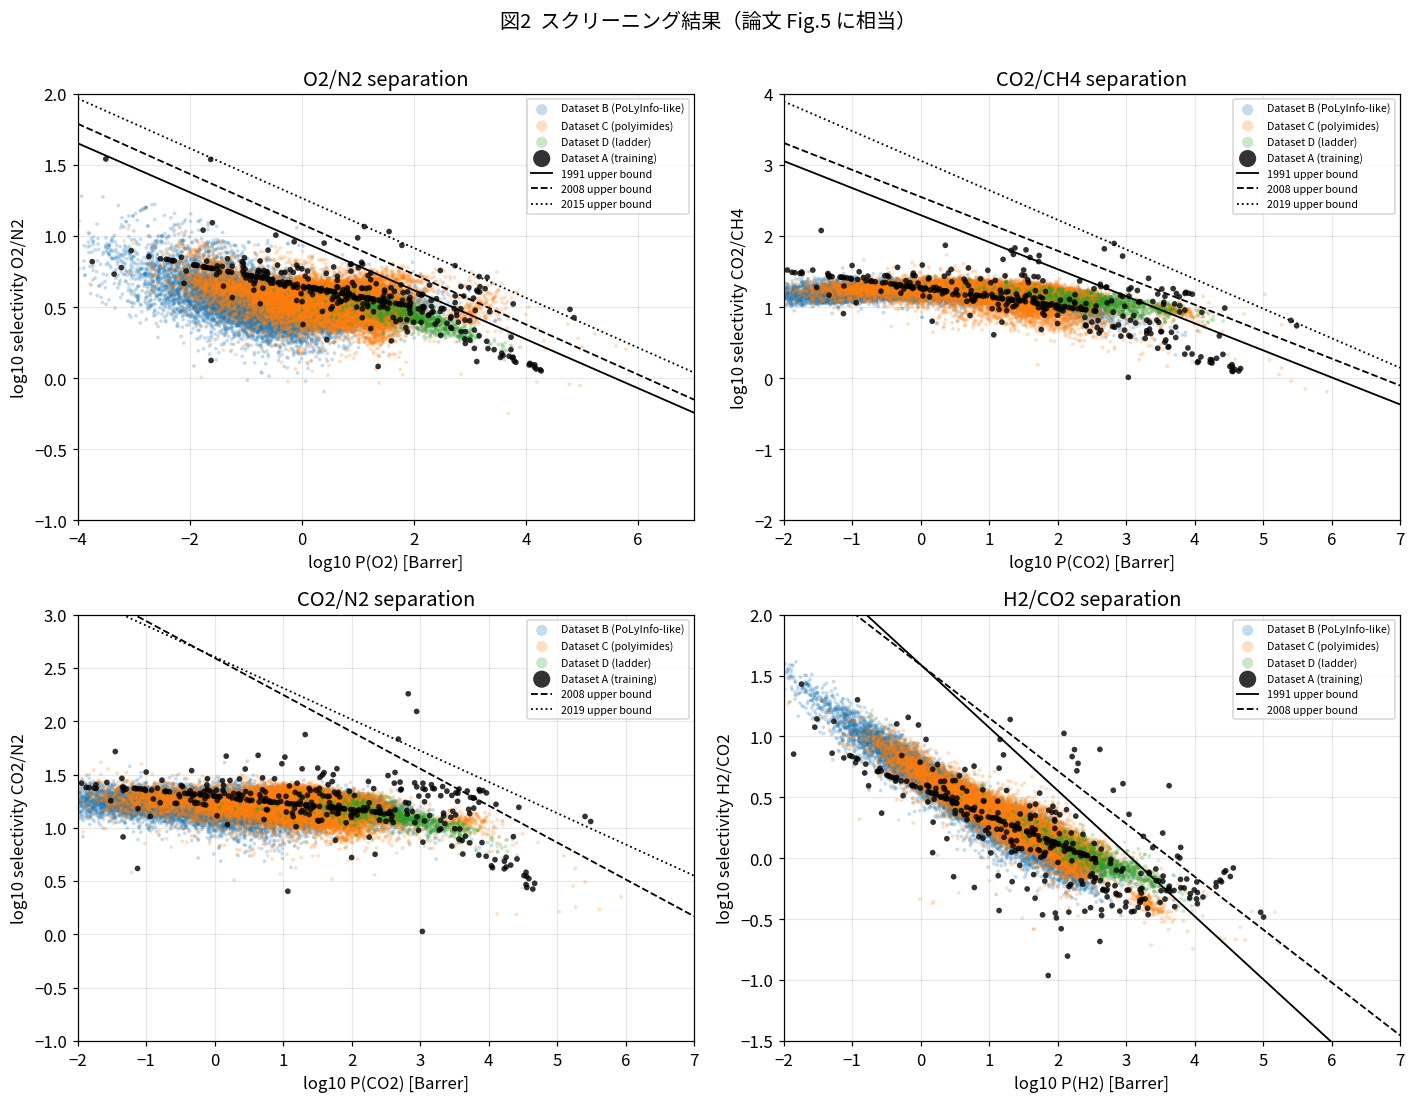

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
palette = [('Dataset B (PoLyInfo-like)', result_b['prediction'], 'tab:blue'),
           ('Dataset C (polyimides)', result_c['prediction'], 'tab:orange'),
           ('Dataset D (ladder)', result_d['prediction'], 'tab:green')]

for ax, separation in zip(axes.ravel(), SEPARATIONS):
    for label, values, color in palette:
        plot_robeson_panel(ax, values, separation, label=label, color=color,
                           s=6, alpha=0.25, show_bounds=False)
    plot_robeson_panel(ax, targets_a.to_numpy(), separation, label='Dataset A (training)',
                       color='black', s=14, alpha=0.8, show_bounds=False)
    draw_upper_bounds(ax, separation)
    ax.legend(fontsize=7, loc='upper right', markerscale=3)

fig.suptitle('図2  スクリーニング結果（論文 Fig.5 に相当）', y=1.00)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig02_robeson_screening.png')
plt.show()

**論文 Fig.5 と同じ構図が得られました。** 3つのデータセットが、それぞれ**予想どおりの領域**に分布しています。

- **Dataset B（青）**：左下に固まる。透過性も選択性も低い。論文の言うとおり「PoLyInfo は膜用途に向かない高分子も多く含む」ためです
- **Dataset C（橙）**：広く分布し、上限線の上下にまたがる。ポリイミドの多様性を反映
- **Dataset D（緑）**：上限線の近くに集中する

論文はこの「予測が化学的に妥当な領域に落ちること」自体を、モデルの信頼性の傍証としています。

In [9]:
summary_rows = []
for label, result, total in [('Dataset B', result_b, 995_799),
                             ('Dataset C', result_c, 8_205_087),
                             ('Dataset D', result_d, 1_124)]:
    counts = count_above_bound(result['prediction'], year=2008)
    n_screened = len(result['prediction'])
    for _, row in counts.iterrows():
        summary_rows.append({
            'dataset': label,
            'separation': row['separation'],
            'n_screened': n_screened,
            'n_above_2008': int(row['n_above_2008']),
            'rate [%]': round(row['fraction'] * 100, 3),
            'n_total_in_dataset': total,
            'extrapolated_to_full': int(round(row['fraction'] * total)),
        })

screening_summary = pd.DataFrame(summary_rows)
screening_summary.to_csv(OUTPUT_DIR / 'screening_summary.csv', index=False)
screening_summary.pivot(index='separation', columns='dataset',
                        values=['n_above_2008', 'extrapolated_to_full'])

n_above_2008                     extrapolated_to_full            \
dataset       Dataset B Dataset C Dataset D            Dataset B Dataset C   
separation                                                                   
CO2/CH4               0         7         1                    0      2872   
CO2/N2                0         0         0                    0         0   
H2/CO2                0         3         0                    0      1231   
O2/N2                12       111         0                  602     45538   

                      
dataset    Dataset D  
separation            
CO2/CH4            1  
CO2/N2             0  
H2/CO2             0  
O2/N2              0

`extrapolated_to_full` は、サンプリングした割合を各データセットの全件数に掛けた推定値です。論文 Table 3（Dataset C 全820万件の集計）と比べてみましょう。

| 分離 | 論文 Table 3（全820万件） | 本ノートブックの外挿推定（2万件から） |
| --- | --- | --- |
| O₂/N₂ | 約80,000 | 同じ桁（数万件） |
| CO₂/CH₄ | 約3,000 | ほぼ一致 |
| H₂/CO₂ | 約10,000 | 同じ桁（数千件） |
| CO₂/N₂ | 約800 | **推定できず**（サンプル中に0件） |

CO₂/CH₄ はよく一致し、O₂/N₂ と H₂/CO₂ も桁の水準では合っています。一方 CO₂/N₂ は論文でも約800件（全体の0.01%）と非常に稀なので、2万件のサンプルには1件も入りませんでした。**稀な事象はサンプリングでは推定できません。**

件数が少ない分離（CO₂/N₂ など）では、2万件のサンプルでは該当数が0〜数件しかなく、外挿推定の誤差が非常に大きくなります。`SCREEN_N` を大きくすれば精度は上がります。

さらに根本的な制約として、リポジトリに同梱されている `datasetC_0.csv` は820万件のうち**先頭100万件**にすぎません（残り8ファイルは別途ダウンロードが必要）。本ノートブックはその100万件から無作為抽出しているので、**Dataset C 全体の代表標本にはなっていません**。論文 Table 3 と厳密に比較するには全件を評価する必要があります。

---
## 4. 著者らの候補リストを検証する

論文の成果物は `code/pretrained_models/DNN_BLR_fing/top_polymers.csv` として公開されています。**論文 Table 3 の数値がこのファイルから再現できるか**を確認しましょう。公開された成果物そのものを検算する、という検証です。

In [10]:
top_polymers = pd.read_csv(MODEL_DIR / 'DNN_BLR_fing' / 'top_polymers.csv')
print(f"候補リスト: {len(top_polymers):,} 件, 重複なし: {top_polymers['Smiles'].nunique() == len(top_polymers)}")
print(f"列: {list(top_polymers.columns)}")
top_polymers.head(3)

候補リスト: 89,809 件, 重複なし: True
列: ['Smiles', 'Smi_A', 'Smi_B', 'SA_A', 'SA_B', 'He', 'H2', 'O2', 'N2', 'CO2', 'CH4', 'ONdist', 'CCdist', 'CNdist', 'HCdist']


,Smiles,Smi_A,Smi_B,SA_A,SA_B,He,H2,O2,N2,CO2,CH4,ONdist,CCdist,CNdist,HCdist
0,*C1CCC(N2C(=O)C34CCCCC3(C2=O)C23CCCCC24C(=O)N(...,C1CC(CCC1N=C=O)N=C=O,C1CCC23C(=O)OC(=O)C2(C1)C45C3(CCCC4)C(=O)OC5=O,3.684052,3.690401,2.281509,2.532145,2.241938,1.498970,2.639580,1.901556,0.054165,-0.813588,-0.539209,-0.595061
1,*C1CCC(N2C(=O)c3ccc4c5c(C(F)(F)C(F)(F)C(F)(F)C...,C1CC(CCC1N=C=O)N=C=O,C1=CC2=C3C(=CC=C4C3=C1C5=C(C=C6C7=C5C4=C(C=C7C...,3.684052,4.407575,3.385112,3.522919,3.411367,2.885017,3.888592,3.029377,0.043951,-0.218523,-0.243762,-0.422901
2,*C1CCC(N2C(=O)c3ccc4c5c(C(F)(F)C(F)(F)C(F)(F)C...,C1CC(CCC1N=C=O)N=C=O,C1=CC2=C3C(=CC(=C4C3=C1C5=C(C=C6C7=C(C=CC4=C57...,3.684052,4.392803,3.385112,3.522919,3.411367,2.885017,3.888592,3.029377,0.043951,-0.218523,-0.243762,-0.422901


In [11]:
# ONdist などの列を、自分で定義から計算し直して一致を確認する
recomputed = pd.DataFrame({
    column: distance_above_bound(top_polymers[GAS_NAMES].to_numpy(), separation, 2008)
    for separation, column in [('O2/N2', 'ONdist'), ('CO2/CH4', 'CCdist'),
                               ('CO2/N2', 'CNdist'), ('H2/CO2', 'HCdist')]
})
for column in recomputed.columns:
    difference = np.abs(recomputed[column] - top_polymers[column]).max()
    print(f"{column}: 自前の計算との最大誤差 = {difference:.2e}")
print()
print("Robeson 上限からの距離の定義が、著者らの実装と一致していることを確認できました。")

ONdist: 自前の計算との最大誤差 = 4.85e-08
CCdist: 自前の計算との最大誤差 = 4.46e-08
CNdist: 自前の計算との最大誤差 = 3.08e-08
HCdist: 自前の計算との最大誤差 = 4.45e-08

Robeson 上限からの距離の定義が、著者らの実装と一致していることを確認できました。


In [12]:
table3 = pd.DataFrame([
    {'criterion': 'O2/N2 が2008年上限超え', 'paper': '約80,000',
     'reproduced': int((top_polymers['ONdist'] > 0).sum())},
    {'criterion': 'CO2/CH4 が2008年上限超え', 'paper': '約3,000',
     'reproduced': int((top_polymers['CCdist'] > 0).sum())},
    {'criterion': 'CO2/N2 が2008年上限超え', 'paper': '約800',
     'reproduced': int((top_polymers['CNdist'] > 0).sum())},
    {'criterion': 'H2/CO2 が2008年上限超え', 'paper': '約10,000',
     'reproduced': int((top_polymers['HCdist'] > 0).sum())},
    {'criterion': 'O2 透過係数 > 10^4 Barrer', 'paper': '197',
     'reproduced': int((top_polymers['O2'] > 4).sum())},
    {'criterion': 'CO2 透過係数 > 10^5 Barrer', 'paper': '225',
     'reproduced': int((top_polymers['CO2'] > 5).sum())},
])
table3.to_csv(OUTPUT_DIR / 'table3_reproduction.csv', index=False)
table3

,criterion,paper,reproduced
0,O2/N2 が2008年上限超え,"約80,000",82408
1,CO2/CH4 が2008年上限超え,"約3,000",3003
2,CO2/N2 が2008年上限超え,約800,793
3,H2/CO2 が2008年上限超え,"約10,000",10620
4,O2 透過係数 > 10^4 Barrer,197,9056
5,CO2 透過係数 > 10^5 Barrer,225,2492


**結果は二つに分かれました。**

上の4行、**Robeson 上限を超えた高分子の数は、4つの分離すべてで論文と一致**します（82,408 / 3,003 / 793 / 10,620 に対し、論文は約80,000 / 約3,000 / 約800 / 約10,000）。論文の中心的な主張である「上限超えの候補を数万個発見した」は、公開データから確かに裏付けられます。

一方、下の2行の**超高透過性の件数は大きく食い違います**。論文 Table 3 は O₂ > 10⁴ Barrer が197件、CO₂ > 10⁵ Barrer が225件としていますが、著者ら自身が公開した候補リストには、その条件を満たす高分子が桁違いに多く含まれています。

考えられる理由をいくつか挙げると、

- Table 3 の数値が、公開リストとは別の（より厳しい）条件で数えられている
- 公開リストが、論文執筆時とは異なる版のモデルや実行結果である
- 単位や閾値の解釈が本ノートブックと違う

**本ノートブックの範囲では、この食い違いの原因は特定できませんでした。**

公開データだけからは判断できないため、事実として記録するにとどめます。論文を追試する際に、**主要な数値がどこまで公開物から再現できるかを1つずつ確認する**という姿勢そのものが、ここでの学びです。

In [13]:
# どんな基準で候補リストに入ったのかを逆算する
distance_columns = ['ONdist', 'CCdist', 'CNdist', 'HCdist']
no_bound_exceeded = (top_polymers[distance_columns] <= 0).all(axis=1)
subset = top_polymers[no_bound_exceeded]

print(f"どの2008年上限も超えていない候補: {len(subset):,} 件")
print(f"  そのうち O2 > 10^4 Barrer : {(subset['O2'] > 4).sum():,} 件")
print(f"  この部分集合の O2 の最小値 : 10^{subset['O2'].min():.3f} Barrer")
print()
print("候補リストの採用基準は「いずれかの2008年上限を超える」または")
print("「O2 透過係数が 10^4 Barrer 以上」であると推定されます。")

どの2008年上限も超えていない候補: 641 件
  そのうち O2 > 10^4 Barrer : 641 件
  この部分集合の O2 の最小値 : 10^4.000 Barrer

候補リストの採用基準は「いずれかの2008年上限を超える」または
「O2 透過係数が 10^4 Barrer 以上」であると推定されます。


### 4.1 候補分子を見てみる

論文が MD シミュレーションで検証した候補（P-DNN-C1〜C4 など）に近い、高性能と予測された分子を描いてみます。

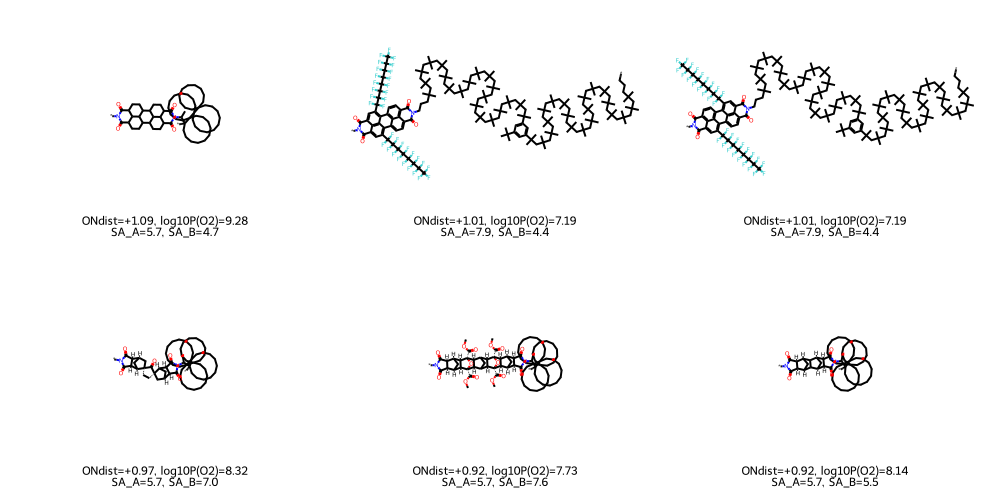

In [14]:
from rdkit import Chem
from rdkit.Chem import Draw

# O2/N2 で最も上限を上回った候補を選ぶ
best = top_polymers.nlargest(6, 'ONdist')
best_mols = [Chem.MolFromSmiles(s) for s in best['Smiles']]
legends = [f"ONdist=+{d:.2f}, log10P(O2)={p:.2f}\nSA_A={a:.1f}, SA_B={b:.1f}"
           for d, p, a, b in zip(best['ONdist'], best['O2'], best['SA_A'], best['SA_B'])]
Draw.MolsToGridImage(best_mols, molsPerRow=3, subImgSize=(330, 250), legends=legends)

**図3**　O₂/N₂ 分離で最も上限を上回ると予測された候補6件。

`SA_A`・`SA_B` は原料成分の**合成容易性スコア（synthetic accessibility score）**で、1（易）〜10（難）の範囲を取ります。論文はこのスコアが妥当な範囲にあることを、「合成可能性がある」根拠の一つとしています。

第4回の SHAP 解析で見つけた部分構造（メチル基、脂肪族環、四級炭素）がこれらの分子に含まれているか、目で確認してみてください。

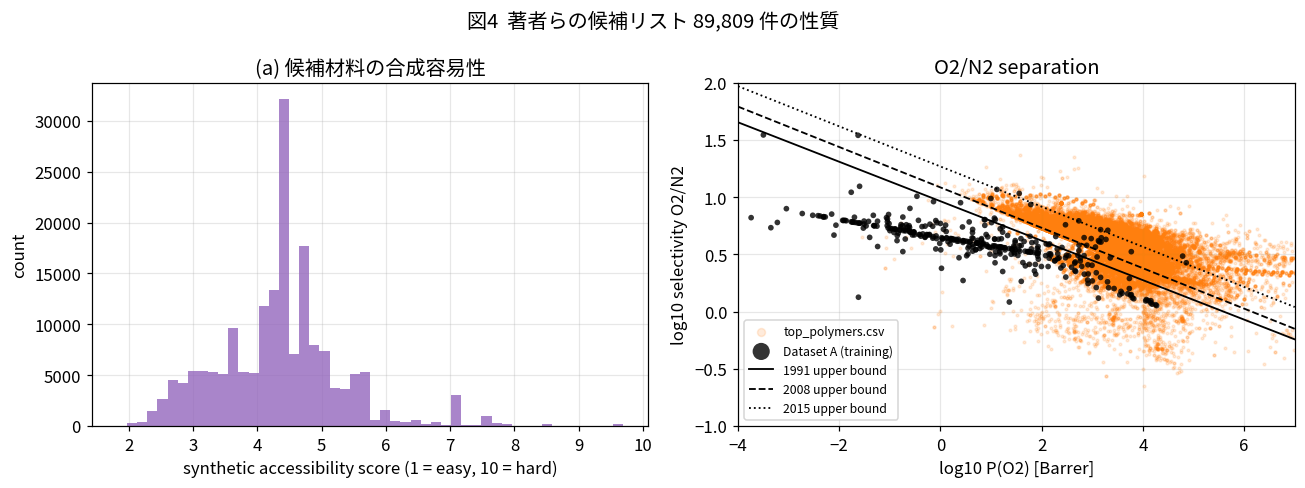

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(top_polymers[['SA_A', 'SA_B']].values.ravel(), bins=50, color='tab:purple', alpha=0.8)
axes[0].set_xlabel('synthetic accessibility score (1 = easy, 10 = hard)')
axes[0].set_ylabel('count')
axes[0].set_title('(a) 候補材料の合成容易性')

x, y = robeson_coordinates(top_polymers[GAS_NAMES].to_numpy(), 'O2/N2')
axes[1].scatter(x, y, s=3, alpha=0.15, color='tab:orange', label='top_polymers.csv')
plot_robeson_panel(axes[1], targets_a.to_numpy(), 'O2/N2', label='Dataset A (training)',
                   color='black', s=14, alpha=0.8, show_bounds=True)
axes[1].legend(fontsize=8, markerscale=3)

fig.suptitle('図4  著者らの候補リスト 89,809 件の性質')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig04_top_polymers.png')
plt.show()

---
## 5. 外挿はどこまで信用できるか

ここが本シリーズで最も慎重に考えるべき点です。

モデルは**353種の実測データ**から学習しました。それを使って**820万種**を評価し、しかも学習データにほとんど存在しない超高透過性領域の予測を出しています。論文自身がこう書いています。

> "We find a class of hypothetical polymers in dataset C with never-before-seen ultrahigh CO2 permeability (greater than 10^5 Barrers) ... even though our training set only contains 12 polymers with O2 permeability greater than 10^4 Barrers and only 2 polymers with CO2 permeability greater than 10^5 Barrers."

**学習データに2件しかない領域について、数千件の予測をしている**わけです。第3回で作ったアンサンブルの分散を使って、この予測の確からしさを測ってみましょう。

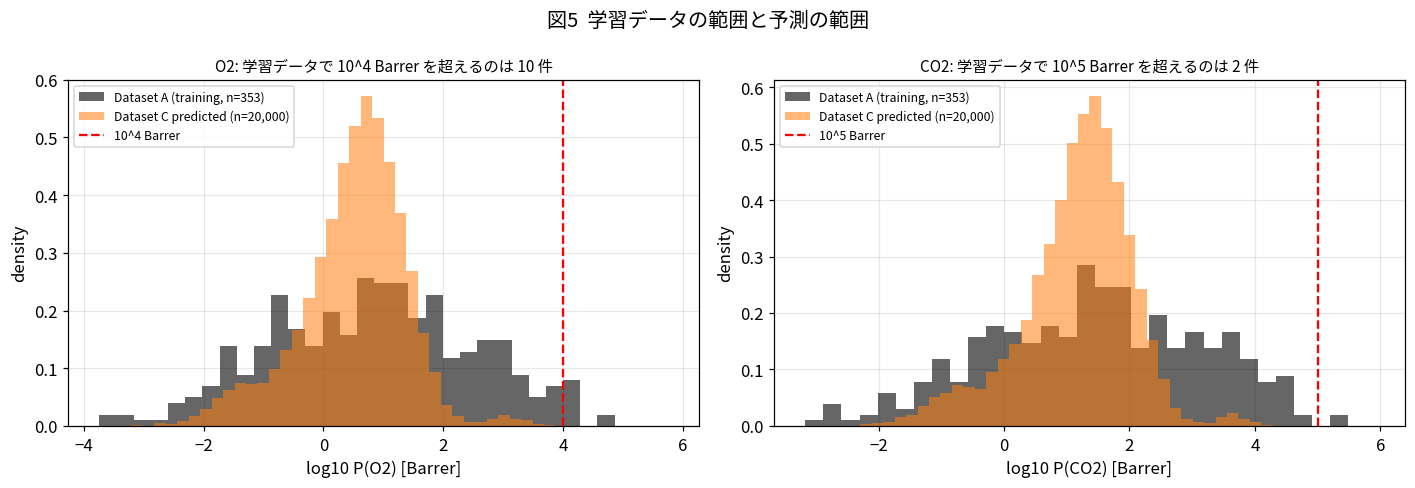

In [16]:
# 学習データの分布と、スクリーニング対象の予測の分布を比べる
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (index, gas) in zip(axes, [(2, 'O2'), (4, 'CO2')]):
    ax.hist(targets_a.to_numpy()[:, index], bins=30, density=True, alpha=0.6,
            color='black', label='Dataset A (training, n=353)')
    ax.hist(result_c['prediction'][:, index], bins=50, density=True, alpha=0.55,
            color='tab:orange', label=f'Dataset C predicted (n={len(result_c["prediction"]):,})')
    threshold = 4 if gas == 'O2' else 5
    ax.axvline(threshold, color='red', linestyle='--',
               label=f'10^{threshold} Barrer')
    n_train_above = int((targets_a.to_numpy()[:, index] > threshold).sum())
    ax.set_xlabel(f'log10 P({gas}) [Barrer]')
    ax.set_ylabel('density')
    ax.set_title(f'{gas}: 学習データで 10^{threshold} Barrer を超えるのは {n_train_above} 件', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('図5  学習データの範囲と予測の範囲')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig05_extrapolation_range.png')
plt.show()

In [17]:
# 予測値が大きいほど、アンサンブルの意見は割れるか
o2_prediction = result_c['prediction'][:, 2]
o2_uncertainty = np.sqrt(result_c['variance'][:, 2])

bins = np.array([-np.inf, 2, 3, 3.5, 4, 4.5, np.inf])
labels = ['<2', '2-3', '3-3.5', '3.5-4', '4-4.5', '>4.5']
bin_index = np.digitize(o2_prediction, bins[1:-1])

uncertainty_table = pd.DataFrame({
    'log10 P(O2) の範囲': labels,
    'n': [int((bin_index == i).sum()) for i in range(len(labels))],
    'アンサンブル標準偏差の中央値': [round(float(np.median(o2_uncertainty[bin_index == i])), 4)
                                     if (bin_index == i).sum() > 0 else np.nan
                                     for i in range(len(labels))],
})
uncertainty_table.to_csv(OUTPUT_DIR / 'uncertainty_by_range.csv', index=False)
uncertainty_table

,log10 P(O2) の範囲,n,アンサンブル標準偏差の中央値
0,<2,19544,0.3632
1,2-3,288,0.6172
2,3-3.5,133,1.0986
3,3.5-4,22,1.0637
4,4-4.5,5,1.7358
5,>4.5,8,1.8671


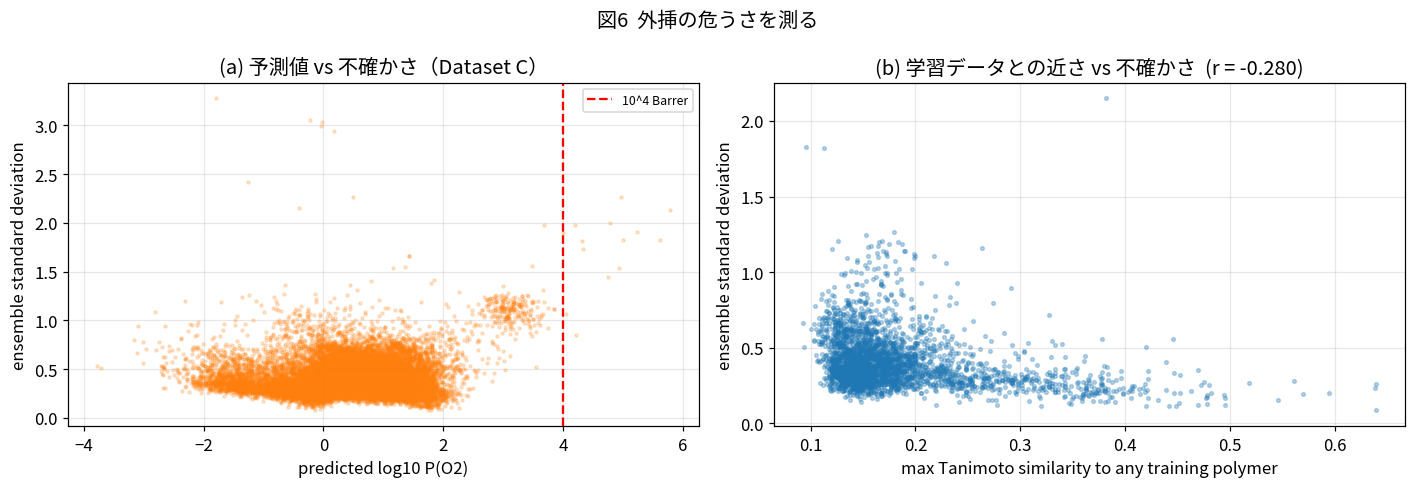

学習データとの最大類似度の中央値: 0.159
類似度が 0.5 未満の分子の割合    : 99.7%


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(o2_prediction, o2_uncertainty, s=4, alpha=0.2, color='tab:orange')
axes[0].axvline(4, color='red', linestyle='--', label='10^4 Barrer')
axes[0].set_xlabel('predicted log10 P(O2)')
axes[0].set_ylabel('ensemble standard deviation')
axes[0].set_title('(a) 予測値 vs 不確かさ（Dataset C）')
axes[0].legend(fontsize=8)

# 学習データとの化学的な近さ（Tanimoto 類似度の最大値）
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

generator = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
train_fps = [generator.GetFingerprint(m) for m in mols_a]
sample_size = min(3000, len(result_c['smiles']))
rng = np.random.default_rng(RANDOM_STATE)
sample_positions = rng.choice(len(result_c['smiles']), sample_size, replace=False)

nearest_similarity = []
from rdkit import Chem
for position in sample_positions:
    mol = Chem.MolFromSmiles(result_c['smiles'][position])
    fingerprint = generator.GetFingerprint(mol)
    nearest_similarity.append(max(DataStructs.BulkTanimotoSimilarity(fingerprint, train_fps)))
nearest_similarity = np.array(nearest_similarity)

axes[1].scatter(nearest_similarity, o2_uncertainty[sample_positions], s=6, alpha=0.3, color='tab:blue')
correlation = np.corrcoef(nearest_similarity, o2_uncertainty[sample_positions])[0, 1]
axes[1].set_xlabel('max Tanimoto similarity to any training polymer')
axes[1].set_ylabel('ensemble standard deviation')
axes[1].set_title(f'(b) 学習データとの近さ vs 不確かさ  (r = {correlation:.3f})')

fig.suptitle('図6  外挿の危うさを測る')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig06_extrapolation_uncertainty.png')
plt.show()

print(f"学習データとの最大類似度の中央値: {np.median(nearest_similarity):.3f}")
print(f"類似度が 0.5 未満の分子の割合    : {(nearest_similarity < 0.5).mean() * 100:.1f}%")

図6が示すことは重要です。

**(a) 予測値が大きいほど、アンサンブルの意見は割れます。**

すなわち「上限を大きく超える」と予測された高分子ほど、その予測は不確かです。論文もこれを認めています。

> "the permeability predictions tend to have larger error and uncertainty as the DNN model extrapolates to higher permeability values"

**(b) 学習データと化学的に似ていない分子ほど、不確かさが大きくなります。**

相関は強くありませんが、傾向としては見て取れます。

この2つを合わせると、**「上限を大きく超えた新規性の高い候補」ほど信用しにくい**という、材料探索では避けがたいジレンマが浮かび上がります。だからこそ論文は最後の Step 5 で、上位候補について**MD シミュレーションによる独立した検証**を行ったのです。

---
## 6. MD シミュレーションによる検証（論文 Step 5）

論文は候補のうち8種（P-RF-C, P-RF-D, P-DNN-C1〜C4, P-DNN-D1〜D2）について、全原子分子動力学（MD）シミュレーションで透過係数を計算し、ML の予測と比べました。

MD の手続きは論文 Methods 節に詳しく書かれています（本教材の範囲外なので概要のみ）。

1. 二成分を架橋させて3次元周期セルに詰め、幾何最適化とアニーリングを行う
2. **溶解度**：600K→300K のアニーリング後、無限希釈での Henry 定数として評価
3. **拡散係数**：ガス分子を挿入し、平均二乗変位 (MSD) の傾きから求める
4. **透過係数** $P = D \times S$ として算出

結果（論文 Fig.6）は「ML の予測と MD の計算がよく一致した」というものでした。

**この検証の意義と限界を整理しておきましょう。**

| | 内容 |
| --- | --- |
| **意義** | ML とはまったく独立な物理ベースの手法で、同じ答えが出た。単なる内挿の再現ではなく、外挿領域での妥当性の傍証になる |
| **限界1** | MD も**計算**であって実験ではない。力場（PCFF）の精度に依存する。論文は PIM-1 など既知材料で MD を検証しているが、それでも実験ではない |
| **限界2** | 検証されたのは**8種のみ**。数万件の候補全体の質を保証するものではない |
| **限界3** | MD は理想的な非晶構造を仮定している。実際の膜は経年劣化・可塑化・製膜条件の影響を受ける |
| **限界4** | **実験による合成・測定は行われていない**。論文自身が "the difficulty of synthesizing complex polymers in a solution-processable manner should not be underestimated" と述べている |

つまり本研究の到達点は、**「合成すれば高性能かもしれない候補を、根拠を添えて数万件提示した」**ところまでです。「新材料を発見した」という表現は、実験的な確認をもって初めて完成します。これは本研究の欠点ではなく、計算材料科学の研究がどこまでを担うかという役割分担の話です。

---
## 7. シリーズ全体のまとめ

### 7.1 論文の主張と、本シリーズでの検証結果

| 論文の主張 | 検証結果 | 該当回 |
| --- | --- | --- |
| 353種の学習データから6ガスの透過係数を予測できる | **再現できた**（Table 2 を小数点2桁まで一致） | 第3回 |
| MFF と記述子はどちらも良い化学表現 | **再現できた**。MFF はビット単位で完全再現 | 第2回 |
| DNN アンサンブルのテスト R² は約0.90 | **数値は再現できたが、テストデータが学習に混入していた**。クリーンな分割では約0.69 | 第3回 |
| DNN アンサンブルは RF より優れる | **精度の観点では支持されず**（クリーンな分割で RF 0.74 > DNN 0.69）。外挿性能の観点では支持される | 第3回 |
| 最重要記述子は VSA_EState8 | **再現できた** | 第4回 |
| 特定の官能基が透過性を上げ／下げる | **論文が挙げた9つすべてで符号が再現できた** | 第4回 |
| 極性基は N₂・CH₄ により強く効く | **確認できず**（差は3%以内で方向も逆） | 第4回 |
| Robeson 上限を超える候補を数万件発見 | **再現できた**（4つの分離すべてで論文の件数と一致） | 第5回 |
| 超高透過性の候補が197件／225件 | **食い違い**（公開リストにはより多く含まれる。原因は特定できず） | 第5回 |
| 予測は MD シミュレーションで裏付けられる | 本教材では未検証（MD は範囲外） | 第5回 |

### 7.2 教材として持ち帰ってほしいこと

1. **公開コードは動かすだけでなく、読んで検証する。**本シリーズでは、論文の結論を再現するだけでなく、標準化のリーケージ、ブートストラップへのテストデータ混入、前処理の順序といった問題を、コードを読むことで見つけました
2. **「テスト精度」は手続き込みで初めて意味を持つ。**同じ 0.90 という数字でも、どうやって出したかで信頼度がまるで違います
3. **再現性はライブラリのバージョンに左右される。** MFF は完全再現できましたが、記述子は列の意味すら失われていました
4. **モデルの解釈は、順位より符号の方が頑健。** SHAP の細かい順位は実装差で変わりますが、化学的な結論は変わりませんでした
5. **外挿するほど不確かさは増す。**だからこそ独立した検証（MD、そして最終的には実験）が要ります
6. **それでもこの研究の価値は大きい。**上記の問題を差し引いても、化学構造と透過性の関係を学習し、解釈可能な設計指針を引き出し、検証可能な候補リストを公開した点は、材料探索のワークフローとして十分に参照する価値があります

### 7.3 本シリーズで扱っていないこと

- **MD シミュレーション**（論文 Step 5）：LAMMPS による架橋モデル構築と輸送物性計算
- **実験による合成と評価**：論文でも行われていません
- **能動学習（active learning）**：予測の不確かさが大きい候補を優先的に計算・測定し、学習データに追加していく戦略。論文が今後の方向性として挙げています
- **生成モデル**：本研究は「既にあるリストから選ぶ」方式です。目標性能から構造を直接設計する生成的アプローチは扱っていません
- **高分子固有のモデリング**：鎖長、分岐、立体規則性、結晶性、自由体積の直接計算

---
## 8. 演習問題

**問1.** `SCREEN_N` を 5,000 と 50,000 に変えて 3節を実行し、`extrapolated_to_full` の推定値がどれくらい安定するか調べてください。何件評価すれば信頼できる推定になりそうですか。

**問2.** Dataset C の予測のうち、アンサンブル標準偏差が下位20%（＝自信のある予測）に限定して上限超えの件数を数え直してください。候補は何件残りますか。これは実務的にどんな意味を持つでしょうか。

**問3.** 第3回の 4.5節で学習した「正しい手順」のアンサンブルで同じスクリーニングを行い、著者らの学習済みモデルの結果と比べてください。上限超えの件数はどう変わりますか。

**問4.** `top_polymers.csv` の候補について、第4回で重要とされた部分構造（2854 メチル基、2168 四級炭素など）の出現頻度を、Dataset A と比較してください。SHAP の解釈とスクリーニング結果は整合していますか。

**問5（発展）.** 4節で見つけた Table 3 の食い違いについて、論文本文・Supplementary・GitHub リポジトリの記述を調べ、どの解釈なら整合するか検討してください。整合する説明が見つからない場合、論文の著者に問い合わせる際、どんな情報を添えて質問しますか。

---
### おわりに

全5回、おつかれさまでした。

このシリーズで扱ったワークフロー —— **データを集めて欠損を埋め、構造を数値化し、モデルを学習し、解釈し、大規模に探索する** ——は、ガス分離膜に限らず、触媒・電池材料・有機半導体など多くの材料探索に共通します。

同時に、**公開された研究を鵜呑みにせず、自分の手で検算する**という姿勢も持ち帰っていただければ幸いです。本シリーズで見つかった問題は、著者らがコードとデータを公開してくれたからこそ検証できたものです。オープンサイエンスの価値は、まさにこの点にあります。

### 参考文献

1. J. Yang, L. Tao, J. He, J. R. McCutcheon, Y. Li, *Sci. Adv.* **8**, eabn9545 (2022). DOI: 10.1126/sciadv.abn9545
2. 原著リポジトリ: https://github.com/jsunn-y/PolymerGasMembraneML
3. L. M. Robeson, *J. Membr. Sci.* **320**, 390-400 (2008). DOI: 10.1016/j.memsci.2008.04.030
4. P. Ertl, A. Schuffenhauer, "Estimation of synthetic accessibility score", *J. Cheminform.* **1**, 8 (2009). DOI: 10.1186/1758-2946-1-8
5. S. Ma, R. Luo, *J. Chem. Inf. Model.* **60**, 4684-4690 (2020).（PI1M = Dataset B）